# **Stacked Charts**


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-03-16 22:39:14--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  84.0MB/s    in 1.8s    

2026-03-16 22:39:16 (84.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



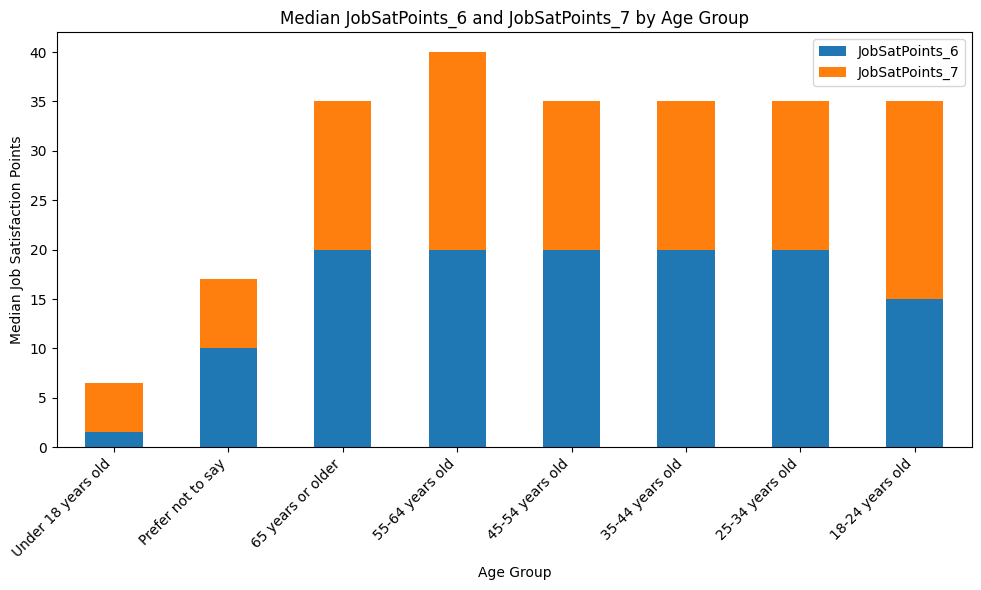

In [7]:
age_job_sat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().sort_values(by='Age', ascending=False)
age_job_sat.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Median JobSatPoints_6 and JobSatPoints_7 by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


/tmp/ipykernel_10516/983956995.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


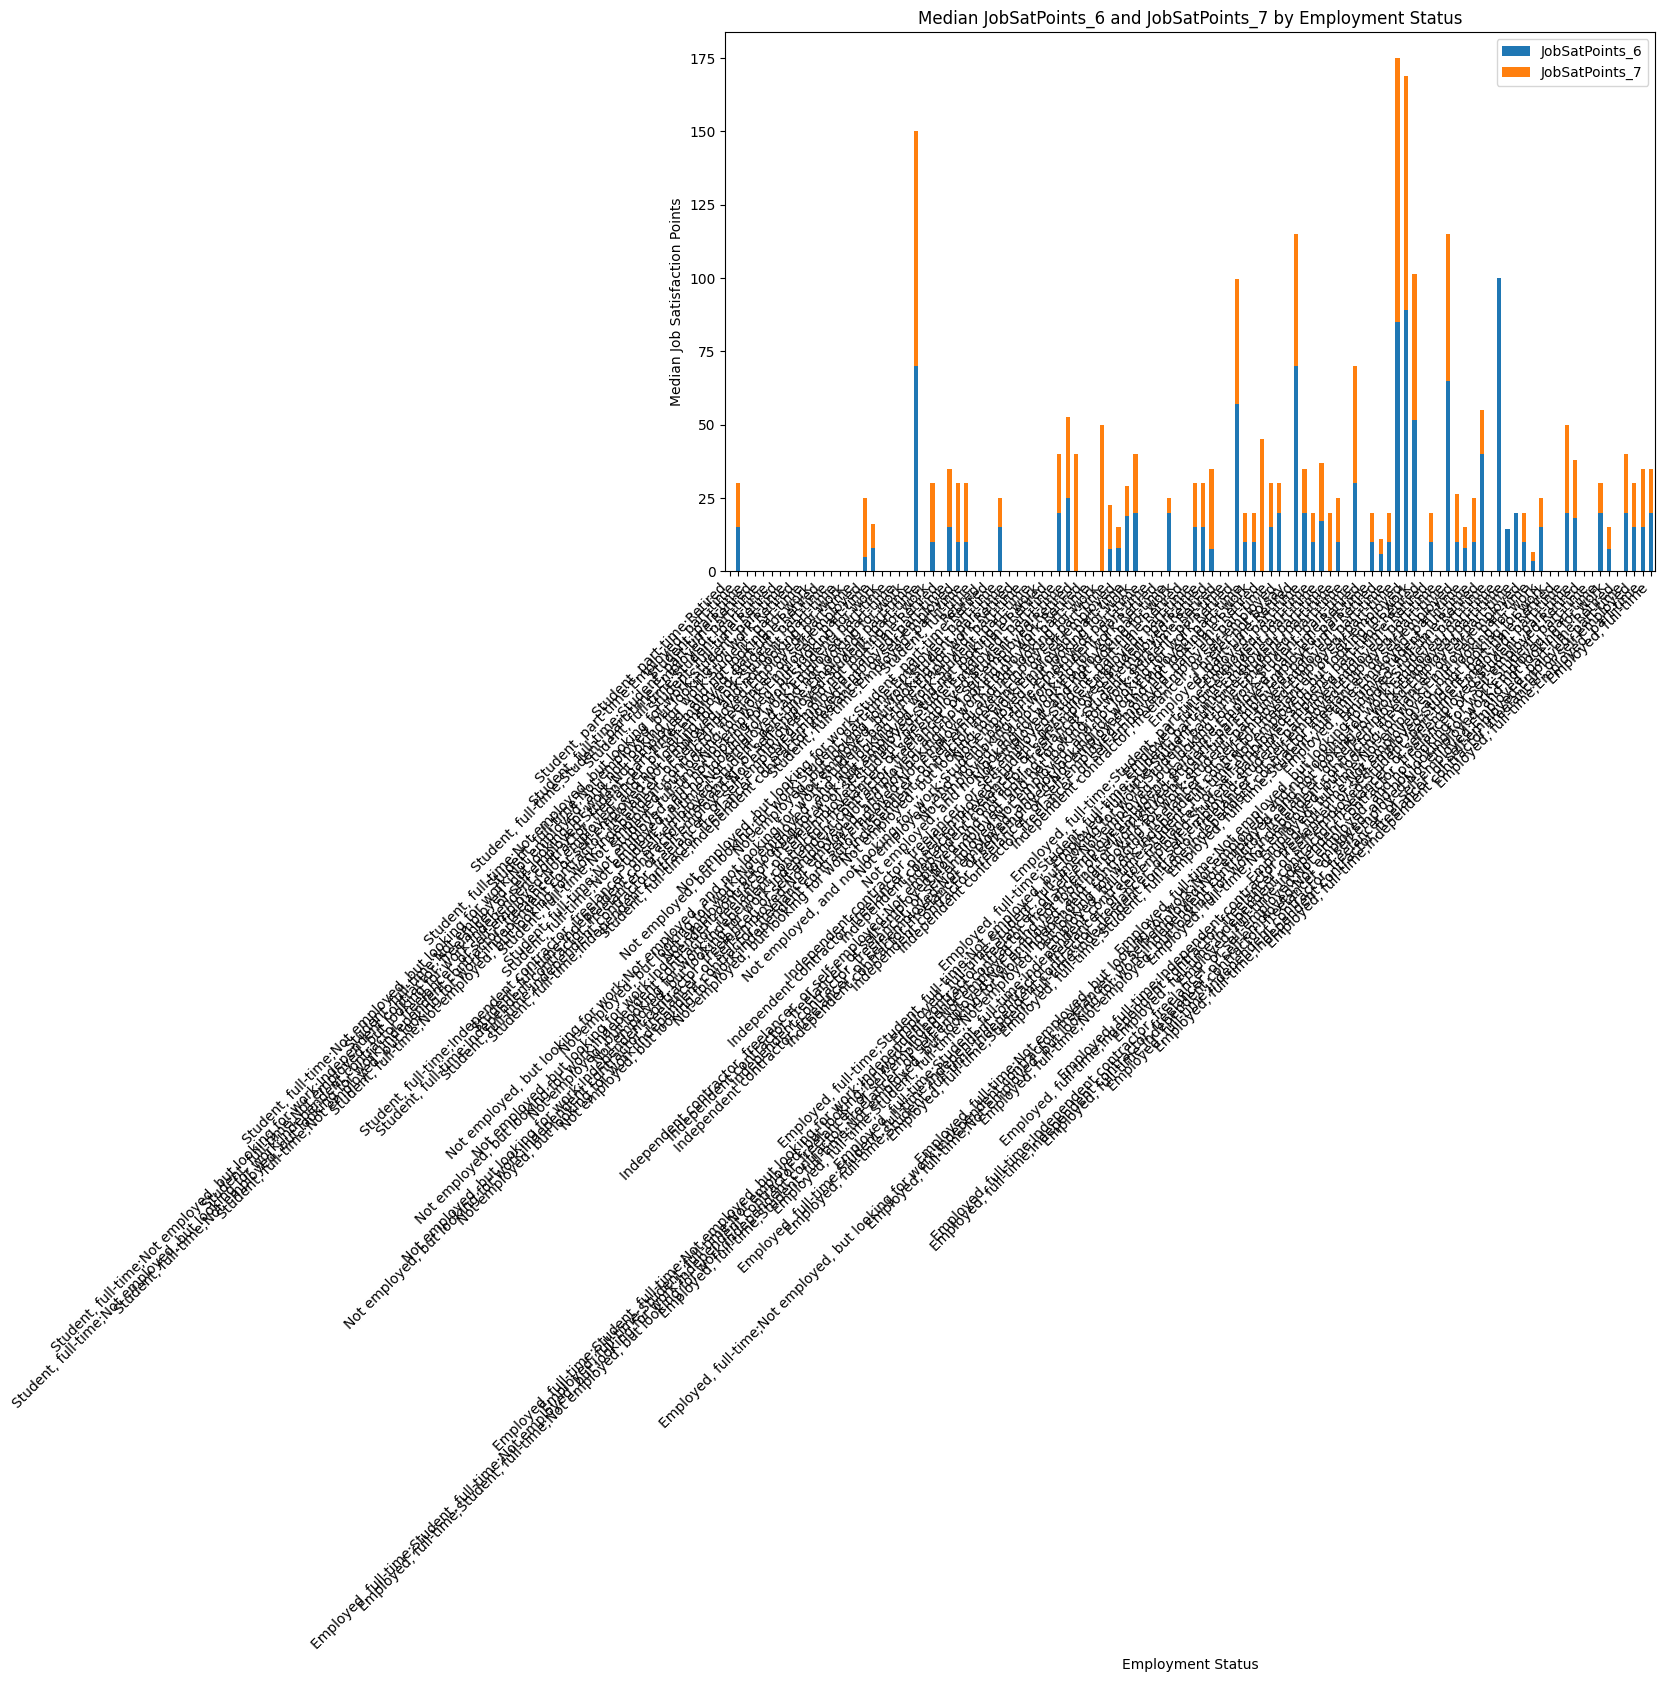

In [8]:
employment_job_sat = df.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median().sort_values(by='Employment', ascending=False)
employment_job_sat.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Median JobSatPoints_6 and JobSatPoints_7 by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


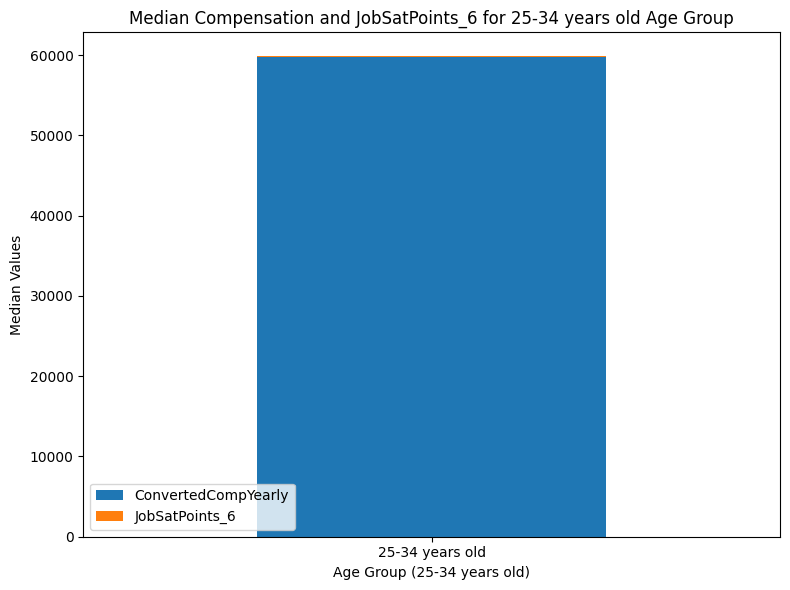

In [10]:
age_group_to_analyze = '25-34 years old'
age_data = df[df['Age'] == age_group_to_analyze]
age_job_comp = age_data.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
age_job_comp.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title(f'Median Compensation and JobSatPoints_6 for {age_group_to_analyze} Age Group')
plt.xlabel(f'Age Group ({age_group_to_analyze})')
plt.ylabel('Median Values')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


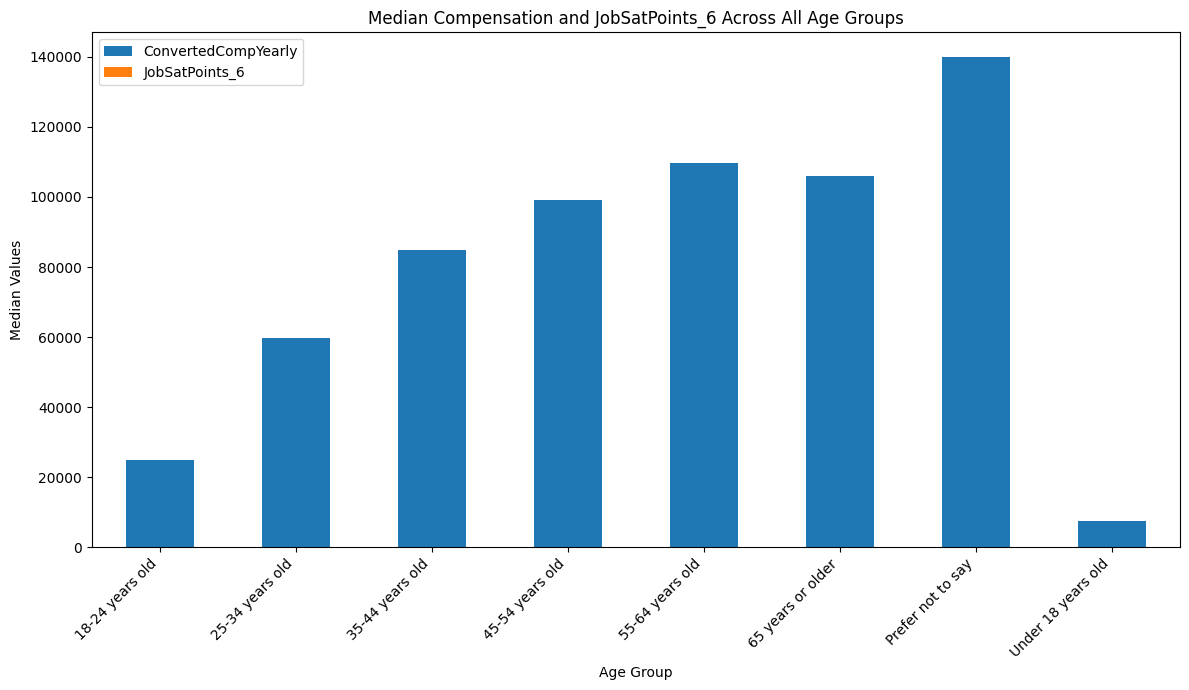

In [11]:
age_comp_job_sat_all = df.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
age_comp_job_sat_all.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Median Compensation and JobSatPoints_6 Across All Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


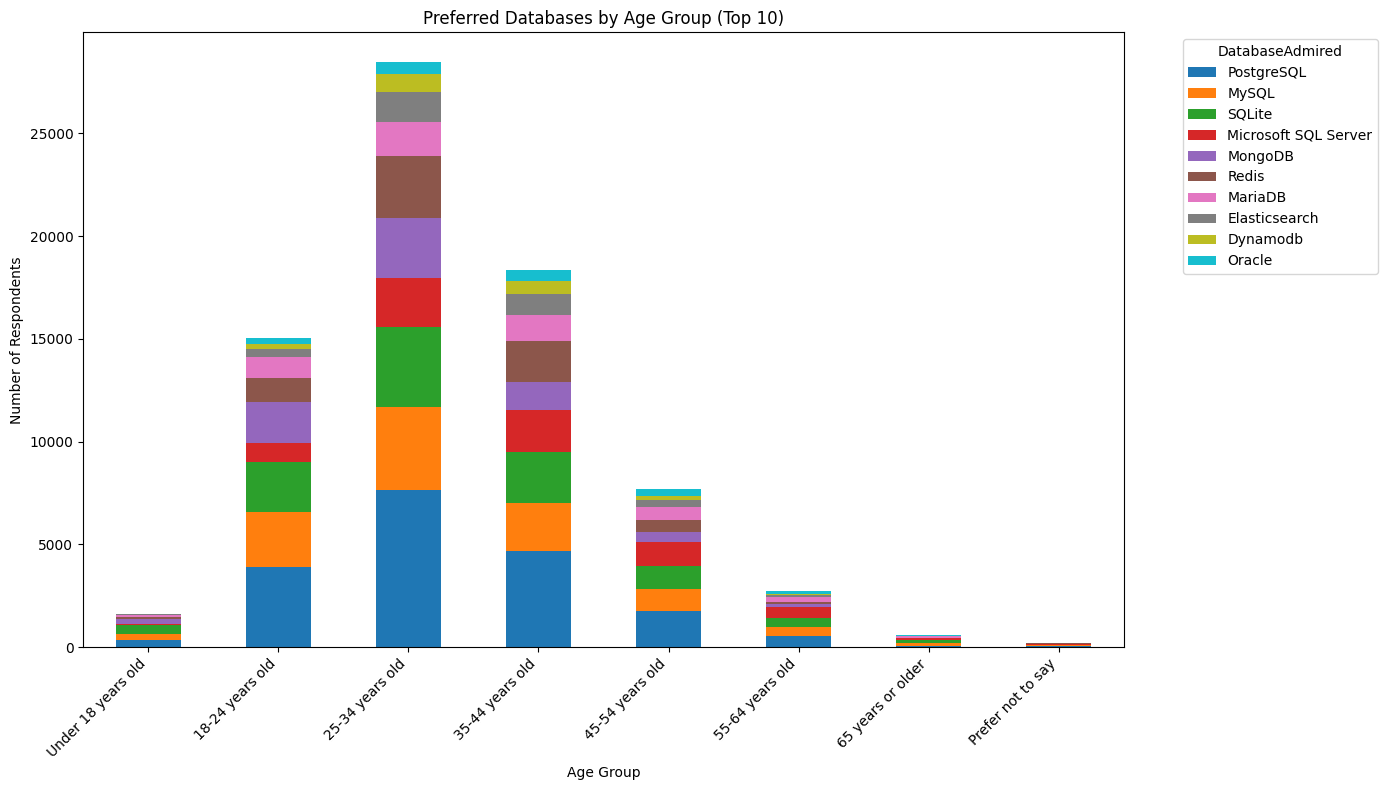

In [12]:
# Clean and prepare the 'DatabaseAdmired' column
df_databases = df.dropna(subset=['DatabaseAdmired']).copy()
df_databases['DatabaseAdmired'] = df_databases['DatabaseAdmired'].apply(lambda x: x.split(';'))
df_databases_exploded = df_databases.explode('DatabaseAdmired')

# Count preferences by Age Group and DatabaseAdmired
database_preferences = df_databases_exploded.groupby(['Age', 'DatabaseAdmired']).size().unstack(fill_value=0)

# Sort age groups for better visualization (assuming 'Age' column has a natural order already or we sort it explicitly)
# You might need to define a custom order for Age if it's not strictly alphanumeric

# For simplicity, let's just use the current index order for Age or define a typical order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]

database_preferences = database_preferences.reindex(age_order, fill_value=0).dropna(how='all')

# Select top N databases to avoid clutter, or plot all if not too many
# For example, let's consider the top 10 most admired databases overall
top_databases = database_preferences.sum().nlargest(10).index
database_preferences_top = database_preferences[top_databases]

# Plotting the stacked bar chart
database_preferences_top.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Preferred Databases by Age Group (Top 10)')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='DatabaseAdmired', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


# Handle missing values in JobSat and Employment
df_employment_sat = df.dropna(subset=['Employment', 'JobSat']).copy()

# Count occurrences of each employment type within each job satisfaction level
employment_sat_counts = df_employment_sat.groupby(['JobSat', 'Employment']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
employment_sat_counts.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Distribution of Employment Types by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
##Write your code here

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


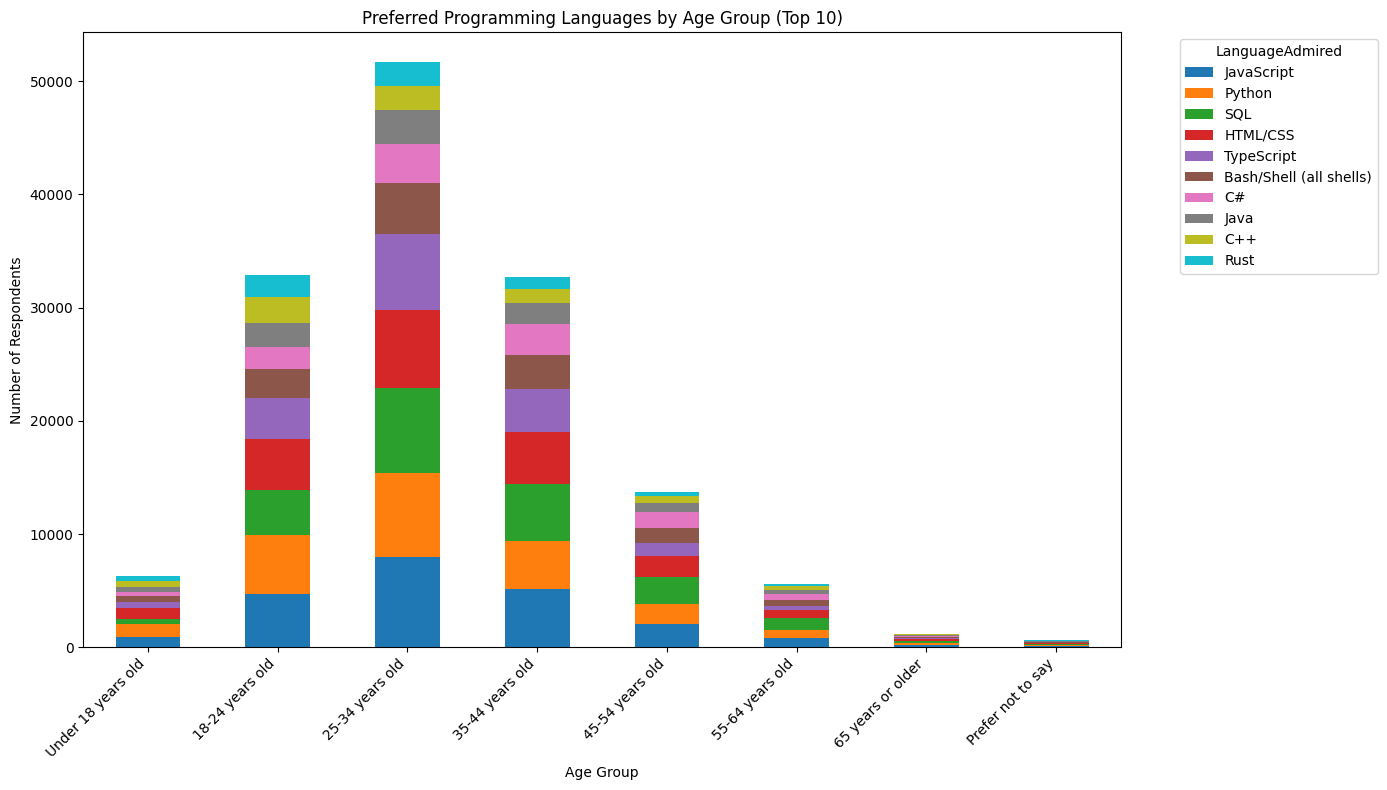

In [13]:
# Clean and prepare the 'LanguageAdmired' column
df_languages = df.dropna(subset=['LanguageAdmired']).copy()
df_languages['LanguageAdmired'] = df_languages['LanguageAdmired'].apply(lambda x: x.split(';'))
df_languages_exploded = df_languages.explode('LanguageAdmired')

# Count preferences by Age Group and LanguageAdmired
language_preferences = df_languages_exploded.groupby(['Age', 'LanguageAdmired']).size().unstack(fill_value=0)

# Sort age groups for better visualization
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]

language_preferences = language_preferences.reindex(age_order, fill_value=0).dropna(how='all')

# Select top N languages to avoid clutter (e.g., top 10)
top_languages = language_preferences.sum().nlargest(10).index
language_preferences_top = language_preferences[top_languages]

# Plotting the stacked bar chart
language_preferences_top.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Preferred Programming Languages by Age Group (Top 10)')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='LanguageAdmired', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


/tmp/ipykernel_10516/1623553702.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


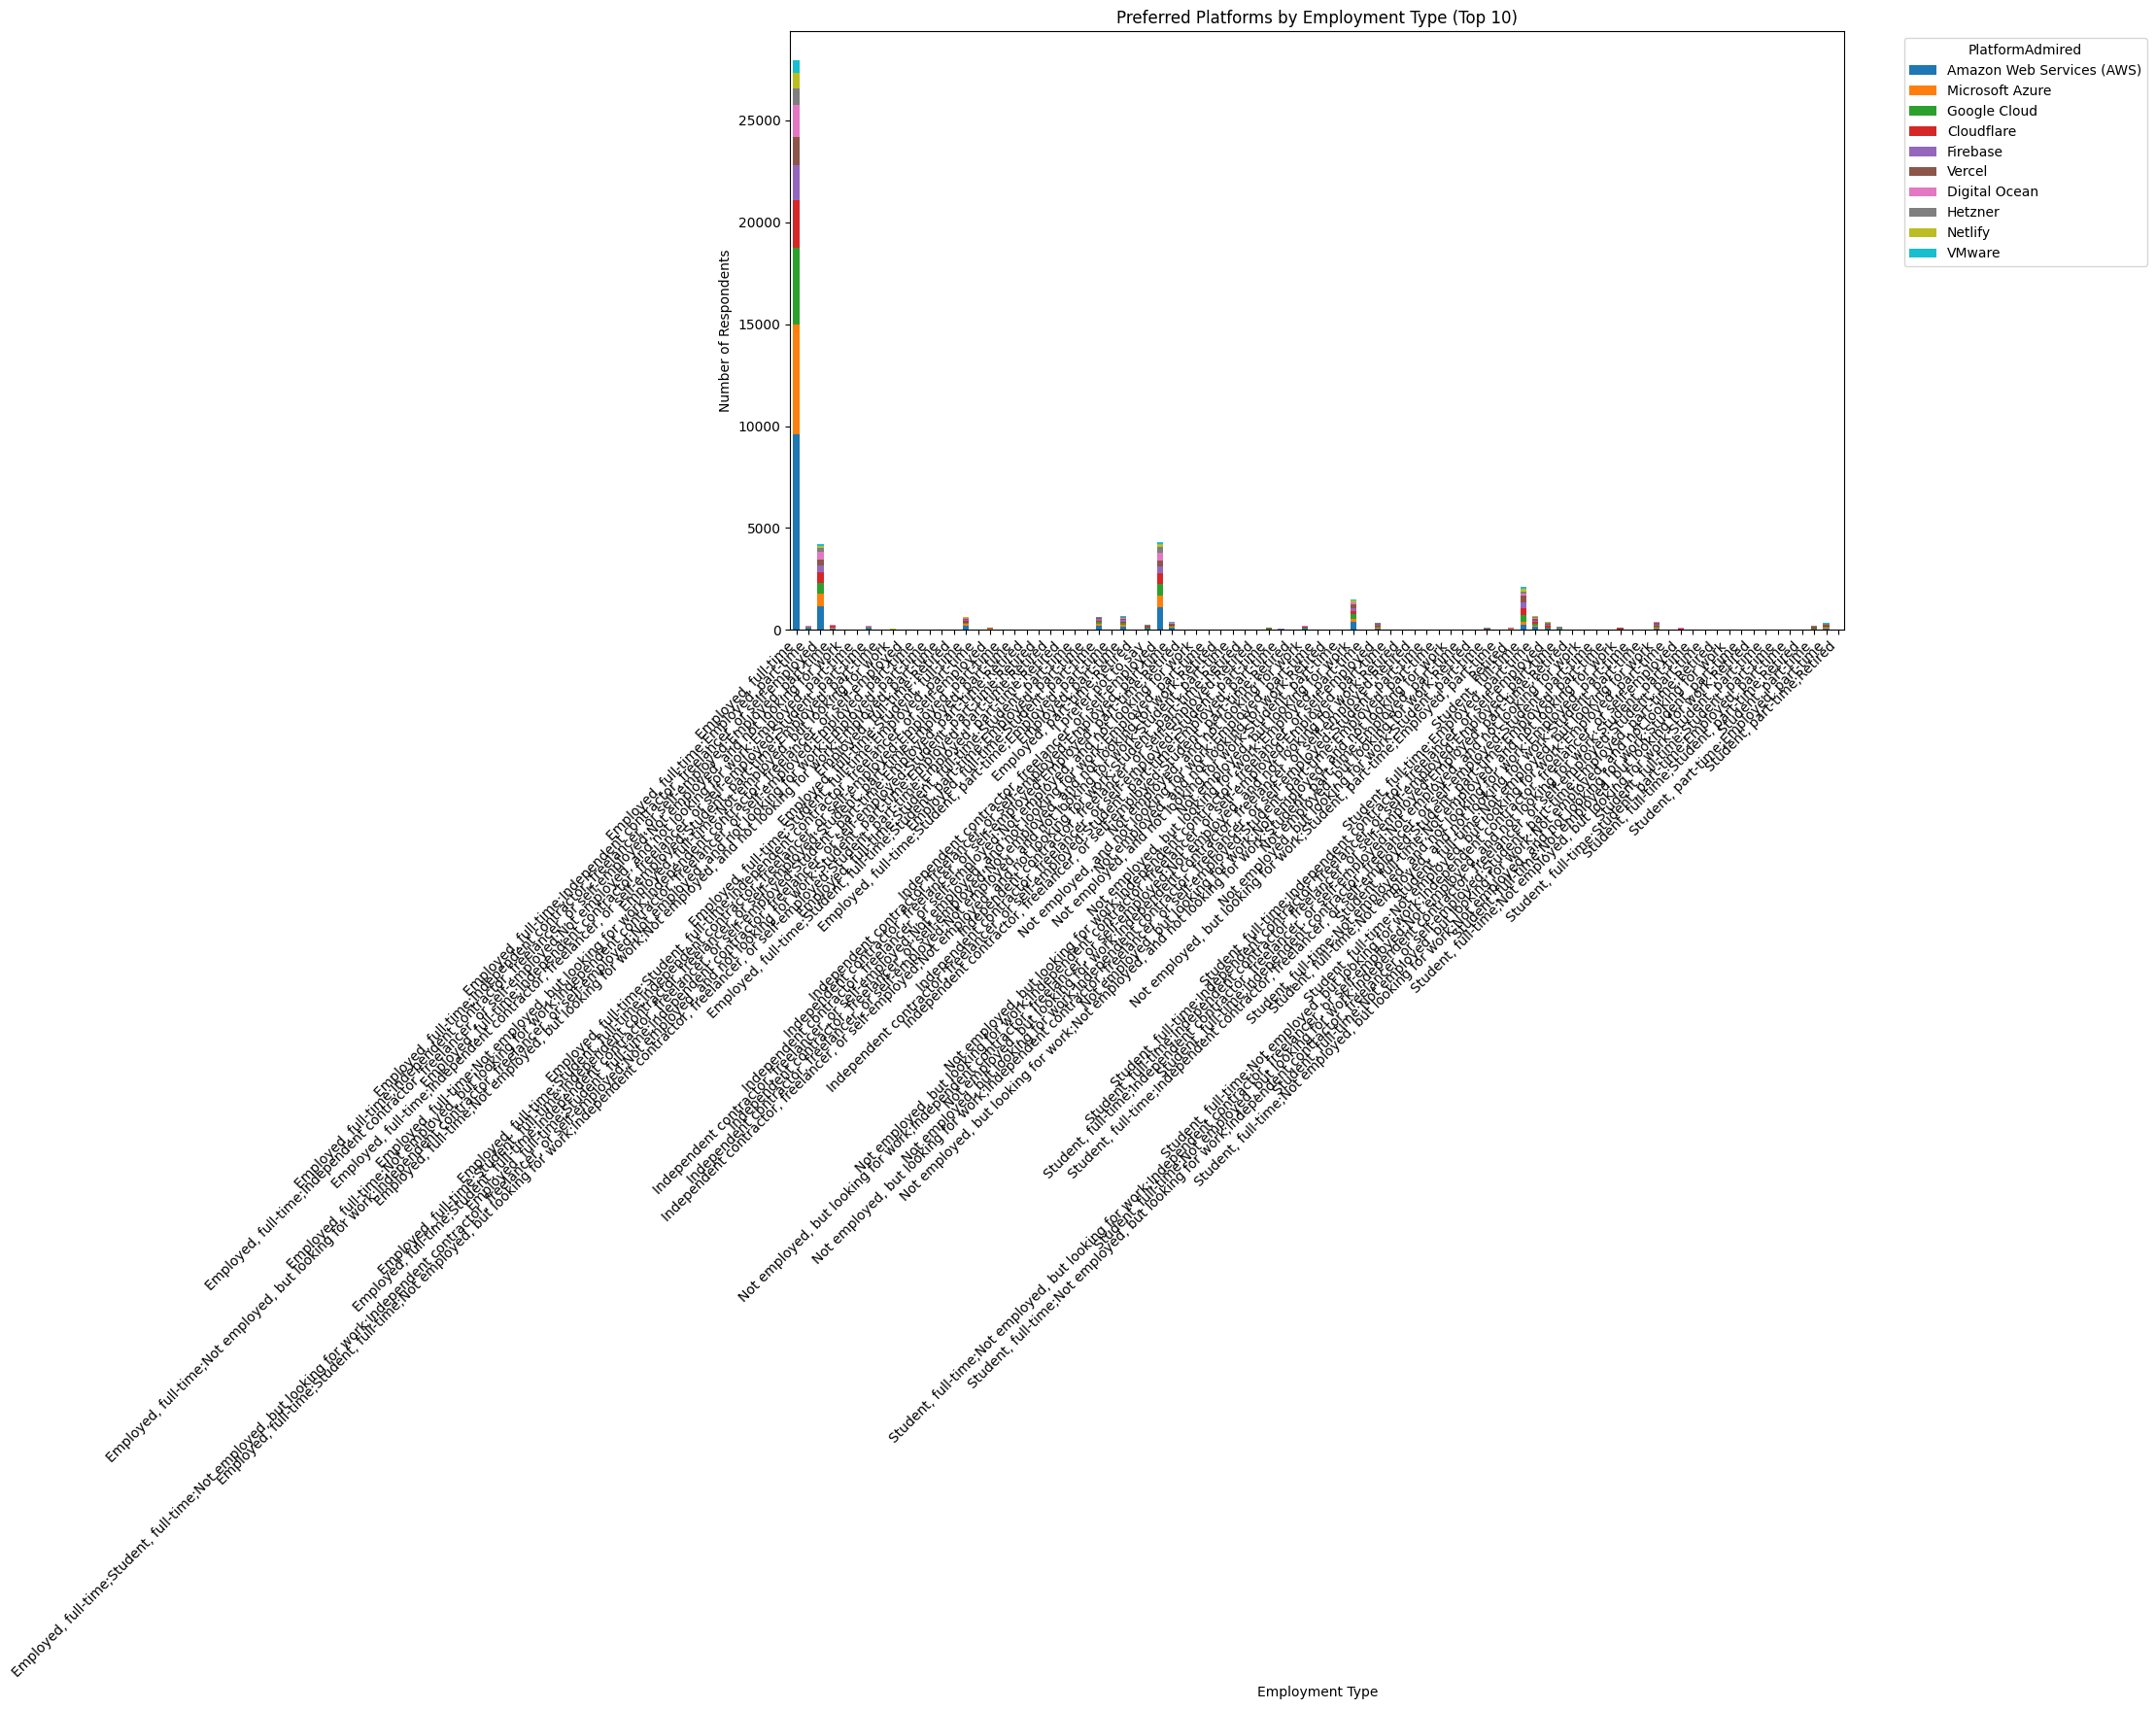

In [14]:
# Clean and prepare the 'PlatformAdmired' column
df_platforms = df.dropna(subset=['PlatformAdmired']).copy()
df_platforms['PlatformAdmired'] = df_platforms['PlatformAdmired'].apply(lambda x: x.split(';'))
df_platforms_exploded = df_platforms.explode('PlatformAdmired')

# Count preferences by Employment Type and PlatformAdmired
platform_preferences = df_platforms_exploded.groupby(['Employment', 'PlatformAdmired']).size().unstack(fill_value=0)

# Select top N platforms to avoid clutter (e.g., top 10)
top_platforms = platform_preferences.sum().nlargest(10).index
platform_preferences_top = platform_preferences[top_platforms]

# Plotting the stacked bar chart
platform_preferences_top.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Preferred Platforms by Employment Type (Top 10)')
plt.xlabel('Employment Type')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='PlatformAdmired', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Sumant chakravarty
